In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [20]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [21]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values (if any)
df.fillna(method='ffill', inplace=True)

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


/tmp/ipykernel_1053/3586210642.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

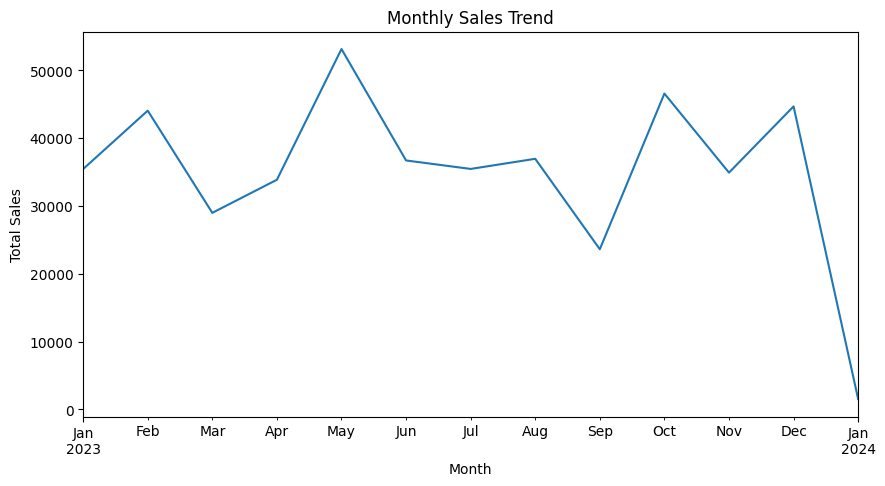

In [23]:
df['Month'] = df['Date'].dt.to_period('M')

df.groupby('Month')['Total Amount'].sum().plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

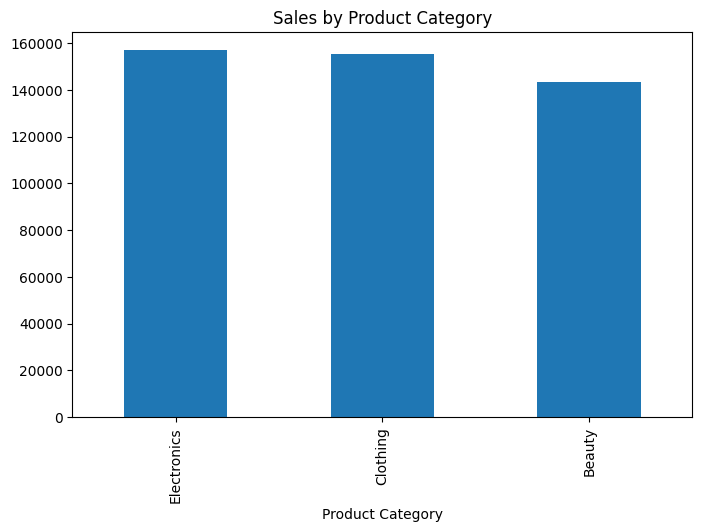

In [24]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title("Sales by Product Category")
plt.show()

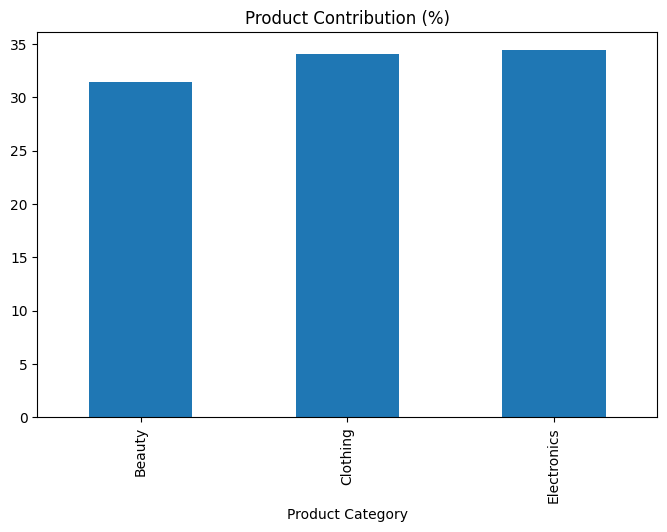

In [25]:
product_sales = df.groupby('Product Category')['Total Amount'].sum()

(product_sales / product_sales.sum() * 100).plot(kind='bar', figsize=(8,5))
plt.title("Product Contribution (%)")
plt.show()

In [26]:
df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


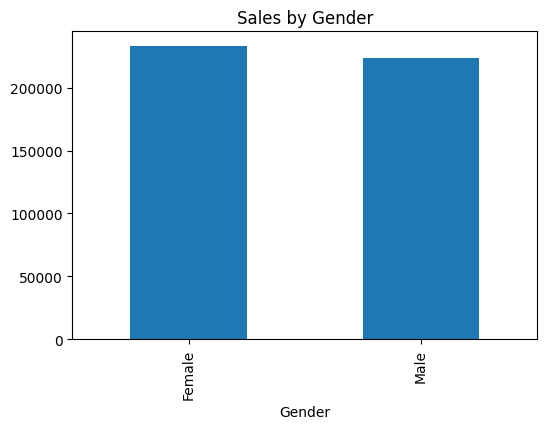

In [27]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar', figsize=(6,4))
plt.title("Sales by Gender")
plt.show()

/tmp/ipykernel_1053/2763114333.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')['Total Amount'].mean().plot(kind='bar', figsize=(8,5))


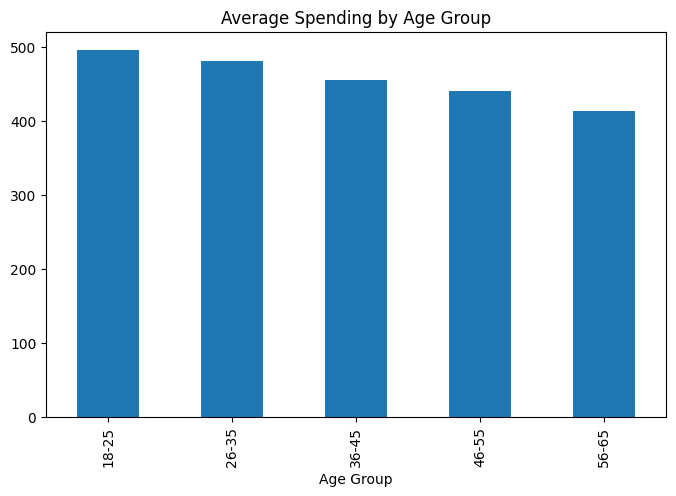

In [28]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.groupby('Age Group')['Total Amount'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Spending by Age Group")
plt.show()

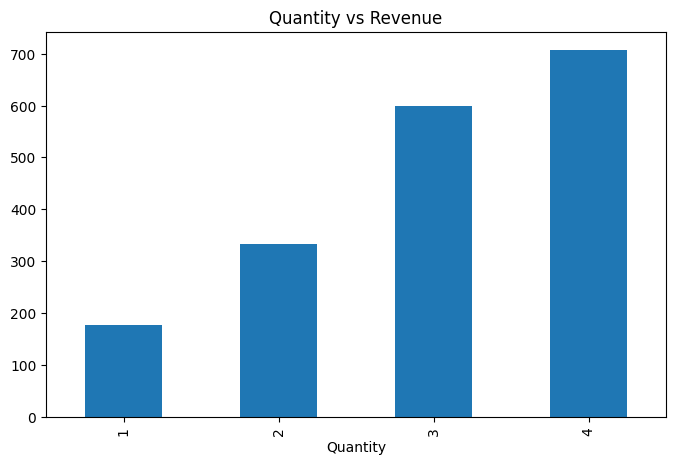

In [29]:
df.groupby('Quantity')['Total Amount'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Quantity vs Revenue")
plt.show()

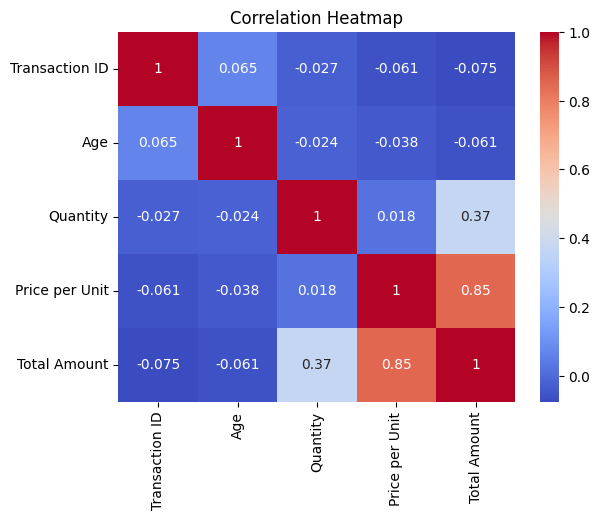

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

***Insights***


Monthly sales show fluctuations, indicating possible seasonal demand patterns.
Electronics and Clothing categories generate the highest revenue.
A small number of customers contribute significantly to total sales.
Female customers contribute slightly more to total sales than males.
Customers aged 26–35 tend to spend more on average.
Higher quantity purchases are associated with increased revenue.

---



***Business Recommendations***



Focus marketing efforts on high-performing product categories like Electronics and Clothing.
Target customers aged 26–35 with personalized promotions.
Offer discounts for bulk purchases to increase revenue.
Analyze peak sales months and plan seasonal marketing campaigns.